# Lendo a base de dados e fazendo validações

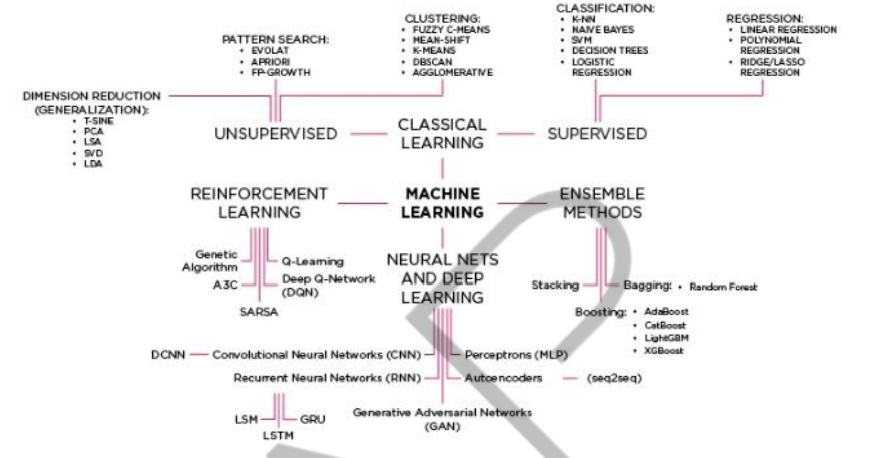

In [5041]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [5042]:
ibovespa = pd.read_csv(r"../data/trusted/ibovespa_historico.csv", sep=';')
ibovespa["data"] = pd.to_datetime(ibovespa["data"])
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar,cotacao_dia_sep_500,cotacao_petroleo
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,5.2109,6861.89,71.27
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,5.2359,6881.31,69.77
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,5.2196,6836.17,67.75
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,5.2120,6832.76,67.52
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,5.1836,6941.47,69.40


In [5043]:
ibovespa[["abertura", "maxima", "minima", "fechamento", "variacao_percentual"]].describe()

,abertura,maxima,minima,fechamento,variacao_percentual
count,534.000000,534.000000,534.000000,534.000000,534.000000
mean,135.653060,136.561036,134.888457,135.754279,0.067959
std,13.813322,14.069473,13.746830,14.000180,0.916199
min,118.534000,119.451000,118.223000,118.533000,-4.310000
25%,127.223000,127.871250,126.448750,127.227500,-0.447500
50%,131.168000,131.867500,130.424000,131.168500,0.050000
75%,138.852250,139.396500,137.987500,138.879750,0.590000
max,189.694000,190.561000,186.959000,189.699000,3.330000


# Feature Engineering

In [5046]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar,cotacao_dia_sep_500,cotacao_petroleo
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,5.2109,6861.89,71.27
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,5.2359,6881.31,69.77
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,5.2196,6836.17,67.75
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,5.2120,6832.76,67.52
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,5.1836,6941.47,69.40


In [5047]:
ibovespa.rename(columns={'data': 'ds'}, inplace=True)

In [5048]:
ibovespa.sort_values(by='ds', inplace=True)

In [5049]:
ibovespa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 534 entries, 533 to 0
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ds                   534 non-null    datetime64[ns]
 1   abertura             534 non-null    float64       
 2   maxima               534 non-null    float64       
 3   minima               534 non-null    float64       
 4   fechamento           534 non-null    float64       
 5   vol_reais            534 non-null    float64       
 6   variacao_percentual  534 non-null    float64       
 7   cotacao_dia_dolar    534 non-null    float64       
 8   cotacao_dia_sep_500  519 non-null    float64       
 9   cotacao_petroleo     534 non-null    float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 45.9 KB


In [5050]:
# features possíveis
ibovespa["vol_log"] = np.log1p(ibovespa["vol_reais"])
ibovespa["range"] = (ibovespa["maxima"] - ibovespa["minima"]) / ibovespa["fechamento"]

In [5051]:
ibovespa["body"] = (ibovespa["fechamento"] - ibovespa["abertura"]) / ibovespa["abertura"]
ibovespa["upper_shadow"] = (ibovespa["maxima"] - ibovespa["fechamento"]) / ibovespa["fechamento"]
ibovespa["lower_shadow"] = (ibovespa["fechamento"] - ibovespa["minima"]) / ibovespa["fechamento"]

Body - O tamanho do corpo do candle em termos percentuais.
fechamento > abertura - body positivo (dia comprador)
fechamento < abertura - body negativo (dia vendedor)
muito próximo - indecisão

upper_shadow - Quanto o preço subiu acima do fechamento antes de recuar.
Se for grande: O mercado subiu bastante, mas perdeu força antes de fechar. Indica pressão vendedora no topo
Significa que houve rejeição no topo.

lower_shadow - Quanto o mercado caiu durante o dia mas recuperou antes de fechar.
Houve forte pressão vendedora intraday, mas compradores reagiram. Pode indicar suporte
Mostra recuperação forte.

In [5052]:
ibovespa["ret_1"] = ibovespa["variacao_percentual"]
ibovespa["ret_2"] = ibovespa["variacao_percentual"].shift(1)
ibovespa["ret_3"] = ibovespa["variacao_percentual"].shift(2)

Retorno: 
ret_1 - retorno de hoje
ret_2 - retorno de ontem
ret_3 - retorno de 2 dias atrás

In [5053]:
ibovespa["volatility_5"] = ibovespa["ret_1"].rolling(5).std()

Desvio padrão dos últimos 5 retornos.

In [5055]:
ibovespa["ret_3d_futuro"] = np.log(ibovespa["fechamento"].shift(-3) / ibovespa["fechamento"])

ibovespa["status"] = (ibovespa["ret_3d_futuro"] > 0).astype(int)

ibovespa = ibovespa.dropna(subset=["status"])

In [5056]:
ibovespa["ma_3"] = ibovespa["fechamento"].rolling(3).mean()
ibovespa["ma_10"] = ibovespa["fechamento"].rolling(10).mean()
ibovespa["trend"] = ibovespa["ma_3"] - ibovespa["ma_10"]

In [5057]:
ibovespa["ret_dolar"] = np.log1p(ibovespa['cotacao_dia_dolar'] / ibovespa['cotacao_dia_dolar'].shift(1))
ibovespa["ret_sp500"] = np.log1p(ibovespa['cotacao_dia_sep_500'] / ibovespa['cotacao_dia_sep_500'].shift(1))
ibovespa["ret_petroleo"] = np.log1p(ibovespa['cotacao_petroleo'] / ibovespa['cotacao_petroleo'].shift(1))

In [5058]:
ibovespa["mm20"] = ibovespa["fechamento"].rolling(20).mean()
ibovespa["dist_mm20"] = (ibovespa["fechamento"] - ibovespa["mm20"]) / ibovespa["mm20"]

In [5059]:
# Se exterior sobe e IBOV já está acima da média, probabilidade de continuação aumenta.
ibovespa["relacao_exterior"] = ibovespa["ret_sp500"]  * ibovespa["mm20"]

In [5060]:
ibovespa.head()

,ds,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar,cotacao_dia_sep_500,cotacao_petroleo,...,status,ma_3,ma_10,trend,ret_dolar,ret_sp500,ret_petroleo,mm20,dist_mm20,relacao_exterior
533,2024-01-02,134.186,134.195,132.095,132.697,8440000.0,-1.11,4.9235,4742.83,75.89,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
532,2024-01-03,132.697,133.576,132.250,132.834,8700000.0,0.10,4.9198,4704.81,78.25,...,0,NaN,NaN,NaN,0.692771,0.689131,0.708576,NaN,NaN,NaN
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,4.8968,4688.68,77.59,...,1,132.252333,NaN,NaN,0.690807,0.691432,0.688921,NaN,NaN,NaN
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,4.8743,4697.24,78.76,...,0,132.027667,NaN,NaN,0.690847,0.694060,0.700659,NaN,NaN,NaN
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,4.8700,4763.54,76.12,...,0,131.892000,NaN,NaN,0.692706,0.700180,0.676245,NaN,NaN,NaN


In [5061]:
# Inclinação da MM20
ibovespa["slope_mm20"] = (ibovespa["mm20"] - ibovespa["mm20"].shift(1)) / ibovespa["mm20"].shift(1)

In [5062]:
# Retorno acumulado 5 dias
ibovespa["ret_5"] = np.log(ibovespa["fechamento"] / ibovespa["fechamento"].shift(5))

In [5063]:
# Volatilidade 10 dias
ibovespa["vol_10"] = ibovespa["fechamento"].rolling(10).std()

In [5064]:
# Distância da MM50 (regime mais longo)
ibovespa["mm50"] = ibovespa["fechamento"].rolling(50).mean()
ibovespa["dist_mm50"] = (ibovespa["fechamento"] - ibovespa["mm50"]) / ibovespa["mm50"]

In [ ]:
ibovespa = ibovespa.dropna()
ibovespa = ibovespa.reset_index(drop=True)
ibovespa = ibovespa.drop(columns=['ret_3d_futuro', 'abertura', 'maxima', 'minima', 'fechamento', 'vol_reais', 'variacao_percentual', 'ma_3', 'ma_10', 'cotacao_dia_dolar', 'cotacao_dia_sep_500', 'cotacao_petroleo', 'mm20', 'mm50',
                                'slope_mm20', 'ret_5', 'vol_10', 'dist_mm50'])

In [5066]:
ibovespa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ds                456 non-null    datetime64[ns]
 1   vol_log           456 non-null    float64       
 2   range             456 non-null    float64       
 3   body              456 non-null    float64       
 4   upper_shadow      456 non-null    float64       
 5   lower_shadow      456 non-null    float64       
 6   ret_1             456 non-null    float64       
 7   ret_2             456 non-null    float64       
 8   ret_3             456 non-null    float64       
 9   volatility_5      456 non-null    float64       
 10  status            456 non-null    int64         
 11  trend             456 non-null    float64       
 12  ret_dolar         456 non-null    float64       
 13  ret_sp500         456 non-null    float64       
 14  ret_petroleo      456 non-

In [5067]:
print(ibovespa.corr()["status"].sort_values())

ret_dolar          -0.034981
body               -0.019140
ret_1              -0.018808
upper_shadow       -0.001565
ret_petroleo        0.008453
volatility_5        0.008534
range               0.020298
lower_shadow        0.024096
ret_sp500           0.046788
dist_mm20           0.060154
relacao_exterior    0.076324
trend               0.083184
ret_2               0.083387
ret_3               0.092656
ds                  0.138052
vol_log             0.170013
status              1.000000
Name: status, dtype: float64


In [5068]:
ibovespa.head()

,ds,vol_log,range,body,upper_shadow,lower_shadow,ret_1,ret_2,ret_3,volatility_5,status,trend,ret_dolar,ret_sp500,ret_petroleo,dist_mm20,relacao_exterior
0,2024-03-13,15.994798,0.008523,0.002647,0.004094,0.004429,0.26,1.22,-0.75,0.892788,0,-0.807800,0.692966,0.692184,0.705943,-0.006691,89.200599
1,2024-03-14,16.044449,0.008333,-0.002360,0.004433,0.003900,-0.25,0.26,1.22,0.881629,0,-0.152800,0.695107,0.691711,0.701384,-0.009099,89.135593
2,2024-03-15,16.522894,0.011480,-0.007362,0.009586,0.001894,-0.74,-0.25,0.26,0.823875,1,-0.217667,0.693688,0.689900,0.692679,-0.015698,88.833896
3,2024-03-18,16.167838,0.009988,0.001546,0.004616,0.005372,0.17,-0.74,-0.25,0.725927,1,-0.429633,0.696186,0.696301,0.702188,-0.013254,89.585593
4,2024-03-19,16.229637,0.008194,0.004521,0.003693,0.004501,0.45,0.17,-0.74,0.476099,0,-0.426400,0.693625,0.695968,0.695963,-0.007864,89.459630


# Treinando o modelo

In [5069]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## Regressão Logística

In [5070]:
train = ibovespa.iloc[:-30]
test = ibovespa.iloc[-30:]

In [5071]:
X_train = train.drop(columns=['ds', 'status'])
X_test = test.drop(columns=['ds', 'status'])

y_train = train['status']
y_test = test['status']

In [5100]:
# Baseline
baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"Baseline (classe majoritária): {baseline:.4f}")

Baseline (classe majoritária): 0.7333


In [5072]:
# print(f" As datas de treino do modelo estão entre {min(train['ds'])} e {max(train['ds'])}")
# print(f" As datas de validação do modelo estão entre {min(test['ds'])} e {max(test['ds'])}")

In [5073]:
X_train.head()

,vol_log,range,body,upper_shadow,lower_shadow,ret_1,ret_2,ret_3,volatility_5,trend,ret_dolar,ret_sp500,ret_petroleo,dist_mm20,relacao_exterior
0,15.994798,0.008523,0.002647,0.004094,0.004429,0.26,1.22,-0.75,0.892788,-0.807800,0.692966,0.692184,0.705943,-0.006691,89.200599
1,16.044449,0.008333,-0.002360,0.004433,0.003900,-0.25,0.26,1.22,0.881629,-0.152800,0.695107,0.691711,0.701384,-0.009099,89.135593
2,16.522894,0.011480,-0.007362,0.009586,0.001894,-0.74,-0.25,0.26,0.823875,-0.217667,0.693688,0.689900,0.692679,-0.015698,88.833896
3,16.167838,0.009988,0.001546,0.004616,0.005372,0.17,-0.74,-0.25,0.725927,-0.429633,0.696186,0.696301,0.702188,-0.013254,89.585593
4,16.229637,0.008194,0.004521,0.003693,0.004501,0.45,0.17,-0.74,0.476099,-0.426400,0.693625,0.695968,0.695963,-0.007864,89.459630


In [5099]:
print(X_test.shape)

(30, 15)


In [5074]:
scaler = StandardScaler()

# Ajusta só no treino
x_train_scaled = scaler.fit_transform(X_train)

# Aplica a transformação no teste
x_test_scaled = scaler.transform(X_test)

Scaler aprende média e desvio padrão

### Fitando o modelo

In [5075]:
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

In [5076]:
# Avaliação
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.6

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.33      0.50      0.40         8
           1       0.78      0.64      0.70        22

    accuracy                           0.60        30
   macro avg       0.56      0.57      0.55        30
weighted avg       0.66      0.60      0.62        30



In [5077]:
print("Acurácia treino:", accuracy_score(y_train, model.predict(x_train_scaled)))
print("Acurácia teste:", accuracy_score(y_test, model.predict(x_test_scaled)))

Acurácia treino: 0.5938967136150235
Acurácia teste: 0.6


### Verificando a possibilidade de Overfitting

In [5078]:
import numpy as np
np.random.seed(42)

y_train_shuffled = np.random.permutation(y_train)
model.fit(x_train_scaled, y_train_shuffled)
y_pred_shuffled = model.predict(x_test_scaled)

print(accuracy_score(y_test, y_pred_shuffled))

0.6666666666666666


O teste de embaralhamento dos rótulos resultou em acurácia próxima de 50%, indicando ausência de vazamento de informação e sugerindo que o modelo aprendeu padrões reais no conjunto de treino. No entanto, o tamanho reduzido do conjunto de teste (30 observações) pode amplificar variações estatísticas na métrica de acurácia.

In [5080]:
# Veficando os coeficientes do modelo
for nome, coef in zip(x_train.columns, model.coef_[0]):
    print(nome, coef)

vol_log 0.0010374746030164398
range 0.043585682098853176
body -0.20498676088561382
upper_shadow -0.21332835155222984
lower_shadow 0.2663732486070174
ret_1 -0.2249988555546197
ret_2 -0.006570871687630151
ret_3 0.07583606287234222
volatility_5 -0.0690240252245956
trend -0.12443293871593411
ret_dolar 0.12509483318040313
ret_sp500 0.015825449555360117
ret_petroleo 0.08825065722414864
dist_mm20 -0.021344452926144397
relacao_exterior 0.05901334183137572


Se uma variável tem: coeficiente positivo → aumenta a chance de Alta (1); coeficiente negativo → aumenta a chance de Baixa (0)

In [5081]:
import numpy as np
np.exp(model.coef_)

array([[1.00103801, 1.04454949, 0.8146581 , 0.80789082, 1.30522214,
        0.79851713, 0.99345067, 1.07878571, 0.93330426, 0.88299747,
        1.13325592, 1.01595134, 1.09226187, 0.97888173, 1.06078939]])

Significa: Um aumento de 1 desvio padrão nessa variável dobra a chance relativa de alta.

In [5082]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(x_test_scaled)[:,1]
roc_auc_score(y_test, y_prob)

0.6761363636363636

	•	Modelo inicial apresentou desempenho artificialmente elevado devido a desalinhamento temporal.
	•	Após correção do target, desempenho caiu para 60%.
	•	Resultado próximo ao baseline indica baixa previsibilidade do retorno diário.
	•	Isso está alinhado com a hipótese de eficiência de mercado.

## KNN

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

for k in [3, 5, 7, 9, 11, 15]:
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=4)),
        ('knn', KNeighborsClassifier(
            n_neighbors=k,
            weights='uniform',   # depois testamos 'distance'
            metric='manhattan'
        ))
    ])
    
    model.fit(X_train, y_train)
    # y_pred = model.predict(X_test)
    
    # acc = accuracy_score(y_test, y_pred)

    # print("Accuracy:", acc)

    # print(f"k={k} → Accuracy: {acc:.4f}")

    # pega probabilidade da classe 1
    probs = model.predict_proba(X_test)[:, 1]

    for t in [0.4, 0.45, 0.5, 0.55, 0.6]:
        y_pred = (probs >= t).astype(int)
        acc = accuracy_score(y_test, y_pred)
        print(f"Threshold={t} → {acc:.4f}")


Threshold=0.4 → 0.5333
Threshold=0.45 → 0.5333
Threshold=0.5 → 0.5333
Threshold=0.55 → 0.5333
Threshold=0.6 → 0.5333
Threshold=0.4 → 0.7000
Threshold=0.45 → 0.5667
Threshold=0.5 → 0.5667
Threshold=0.55 → 0.5667
Threshold=0.6 → 0.5667
Threshold=0.4 → 0.7333
Threshold=0.45 → 0.7000
Threshold=0.5 → 0.7000
Threshold=0.55 → 0.7000
Threshold=0.6 → 0.4667
Threshold=0.4 → 0.7333
Threshold=0.45 → 0.7000
Threshold=0.5 → 0.7000
Threshold=0.55 → 0.7000
Threshold=0.6 → 0.5000
Threshold=0.4 → 0.8000
Threshold=0.45 → 0.8000
Threshold=0.5 → 0.7333
Threshold=0.55 → 0.6667
Threshold=0.6 → 0.6667
Threshold=0.4 → 0.7667
Threshold=0.45 → 0.7667
Threshold=0.5 → 0.7333
Threshold=0.55 → 0.6667
Threshold=0.6 → 0.6667


Threshold é:

A régua que transforma probabilidade em decisão.

Baixo threshold → mais classe 1
Alto threshold → menos classe 1

In [5084]:
for k in [3, 5, 7, 9, 11]:
    for w in ['uniform', 'distance']:
        
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=4)),
            ('knn', KNeighborsClassifier(
                n_neighbors=k,
                weights=w,
                metric='manhattan'
            ))
        ])
        
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        
        print(f"k={k}, weights={w} → {acc:.4f}")

k=3, weights=uniform → 0.5333
k=3, weights=distance → 0.5333
k=5, weights=uniform → 0.5667
k=5, weights=distance → 0.5667
k=7, weights=uniform → 0.7000
k=7, weights=distance → 0.6667
k=9, weights=uniform → 0.7000
k=9, weights=distance → 0.7000
k=11, weights=uniform → 0.7333
k=11, weights=distance → 0.7333


In [5086]:
# Hiperparametro do nosos modelo é o número de vizinhos considerado (n_neighbors)
modelo_classificador = KNeighborsClassifier(n_neighbors=3, weights='distance')

# Está fazendo o treinamento do meu modelo de ML
modelo_classificador.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [5087]:
from sklearn.metrics import accuracy_score

In [5088]:
y_predito = modelo_classificador.predict(x_test_scaled)

In [5089]:
accuracy_score(y_true = y_test, y_pred=y_predito)

0.6333333333333333

## Gradient Boosting (sklearn)

In [5090]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Modelo
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Treino
gb.fit(x_train_scaled, y_train)

# Previsão
y_pred_gb = gb.predict(x_test_scaled)

# Avaliação
print("Accuracy GB:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy GB: 0.7333333333333333
              precision    recall  f1-score   support

           0       0.50      0.75      0.60         8
           1       0.89      0.73      0.80        22

    accuracy                           0.73        30
   macro avg       0.69      0.74      0.70        30
weighted avg       0.79      0.73      0.75        30



In [5091]:
for lr in [0.01, 0.05, 0.1]:
    for depth in [2, 3]:
        gb = GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=lr,
            max_depth=depth,
            random_state=42
        )
        gb.fit(x_train_scaled, y_train)
        acc = accuracy_score(y_test, gb.predict(x_test_scaled))
        print(f"lr={lr}, depth={depth} → {acc:.4f}")

lr=0.01, depth=2 → 0.7333
lr=0.01, depth=3 → 0.6667
lr=0.05, depth=2 → 0.6667
lr=0.05, depth=3 → 0.7333
lr=0.1, depth=2 → 0.6000
lr=0.1, depth=3 → 0.7667


## SVM (com scaler obrigatório)

In [5092]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42,
        class_weight='balanced'
    ))
])

svm_model.fit(x_train_scaled, y_train)

y_pred_svm = svm_model.predict(x_test_scaled)

print("Accuracy SVM:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy SVM: 0.7666666666666667
              precision    recall  f1-score   support

           0       0.55      0.75      0.63         8
           1       0.89      0.77      0.83        22

    accuracy                           0.77        30
   macro avg       0.72      0.76      0.73        30
weighted avg       0.80      0.77      0.78        30



In [5093]:
for C in [0.1, 1, 10]:
    for gamma in ['scale', 0.01, 0.1]:
        svm_model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='rbf', C=C, gamma=gamma))
        ])
        
        svm_model.fit(x_train_scaled, y_train)
        acc = accuracy_score(y_test, svm_model.predict(x_test_scaled))
        
        print(f"C={C}, gamma={gamma} → {acc:.4f}")

C=0.1, gamma=scale → 0.7333
C=0.1, gamma=0.01 → 0.7333
C=0.1, gamma=0.1 → 0.7333
C=1, gamma=scale → 0.8333
C=1, gamma=0.01 → 0.7333
C=1, gamma=0.1 → 0.8333
C=10, gamma=scale → 0.5000
C=10, gamma=0.01 → 0.6333
C=10, gamma=0.1 → 0.6333


## Random Forest

In [5094]:
from sklearn.ensemble import RandomForestClassifier

In [5095]:
rf = RandomForestClassifier(n_estimators=5, max_depth = 2,  random_state=7) 

rf.fit(x_train_scaled, y_train) 
estimator = rf.estimators_
y_predito_random_forest = rf.predict(x_test_scaled)

# Metricas de precisão, revocação, f1-score e acurácia.
print(accuracy_score(y_test, y_predito_random_forest)) #relatório de validação das métrica de desempenho.

0.7333333333333333


In [5096]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   vol_log           426 non-null    float64
 1   range             426 non-null    float64
 2   body              426 non-null    float64
 3   upper_shadow      426 non-null    float64
 4   lower_shadow      426 non-null    float64
 5   ret_1             426 non-null    float64
 6   ret_2             426 non-null    float64
 7   ret_3             426 non-null    float64
 8   volatility_5      426 non-null    float64
 9   trend             426 non-null    float64
 10  ret_dolar         426 non-null    float64
 11  ret_sp500         426 non-null    float64
 12  ret_petroleo      426 non-null    float64
 13  dist_mm20         426 non-null    float64
 14  relacao_exterior  426 non-null    float64
dtypes: float64(15)
memory usage: 50.1 KB
